In [5]:
import os
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from alpaca.data.historical import StockHistoricalDataClient 
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame
from datetime import datetime, timedelta
from ta.momentum import RSIIndicator


load_dotenv(dotenv_path='../.env')
API_KEY = os.getenv('APCA_API_KEY_ID')
API_SECRET = os.getenv('APCA_API_SECRET_KEY')

if not API_KEY or not API_SECRET:
    raise ValueError("API_KEY and API_SECRET must be set in the .env file.")

print ("Starting to pull historical data from Alpaca API...")
client = StockHistoricalDataClient(API_KEY, API_SECRET)

symbol = "AAPL"
request_params = StockBarsRequest(
    symbol_or_symbols=symbol,
    timeframe=TimeFrame.Day,
    start=datetime.now() - timedelta(days=365)
)

bars = client.get_stock_bars(request_params)
df = bars.df

print(f"Data for {symbol} retrieved successfully. Saving to CSV...")

df.tail()


Matplotlib is building the font cache; this may take a moment.


Starting to pull historical data from Alpaca API...
Data for AAPL retrieved successfully. Saving to CSV...


open    high  ...  trade_count        vwap
symbol timestamp                                   ...                         
AAPL   2026-06-12 04:00:00+00:00  296.030  297.14  ...     830866.0  291.579339
       2026-06-15 04:00:00+00:00  294.120  297.78  ...     792074.0  296.015019
       2026-06-16 04:00:00+00:00  295.245  300.48  ...     767541.0  298.486668
       2026-06-17 04:00:00+00:00  300.845  302.07  ...     722928.0  297.116837
       2026-06-18 04:00:00+00:00  298.110  300.57  ...     745683.0  298.101017

[5 rows x 7 columns]

In [10]:
df['SMA_20'] = df['close'].rolling(window=20).mean()
df['SMA_50'] = df['close'].rolling(window=50).mean()
df = df.dropna()
df[['close', 'SMA_20', 'SMA_50']].tail()

close    SMA_20    SMA_50
symbol timestamp                                            
AAPL   2026-06-12 04:00:00+00:00  291.13  303.8810  285.4912
       2026-06-15 04:00:00+00:00  296.42  303.6905  286.3012
       2026-06-16 04:00:00+00:00  299.24  303.7605  287.1088
       2026-06-17 04:00:00+00:00  295.95  303.6095  287.9578
       2026-06-18 04:00:00+00:00  298.01  303.3975  288.7400

In [24]:
df['signal'] = np.where(df['SMA_20'] > df['SMA_50'], 1, 0)
df['position'] = df['signal'].diff()
trades_df = df[df['position'] != 0].copy()
trades_df[['close', 'SMA_20', 'SMA_50', 'signal', 'position']].tail(10)

C:\Users\bodya\AppData\Local\Temp\ipykernel_24448\273400978.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['signal'] = np.where(df['SMA_20'] > df['SMA_50'], 1, 0)
C:\Users\bodya\AppData\Local\Temp\ipykernel_24448\273400978.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['position'] = df['signal'].diff()


close    SMA_20    SMA_50  signal  position
symbol timestamp                                                              
AAPL   2025-09-02 04:00:00+00:00  229.72  227.0790  216.1220       1       NaN
       2026-01-07 05:00:00+00:00  260.33  272.4445  273.0090       0      -1.0
       2026-02-23 05:00:00+00:00  266.18  265.9385  265.8926       1       1.0
       2026-03-18 04:00:00+00:00  249.94  261.3985  261.6448       0      -1.0
       2026-04-23 04:00:00+00:00  273.43  260.4900  260.2342       1       1.0

In [29]:
initial_capital = 10000
captial = initial_capital
shares_held = 0

print("Starting backtest...")
print(f"Initial capital: ${initial_capital}")

for index, row in trades_df.iterrows():
    date = str(index)[:10]
    price = row['close']

    if row['position'] == 1 and shares_held == 0:
        shares_held = captial // price
        captial = 0
        print(f"{date}: Buy {shares_held} shares at ${price:.2f}. Remaining capital: ${captial:.2f}")

    elif row['position'] == -1 and shares_held > 0:
        captial = shares_held * price
        shares_held = 0
        print(f"{date}: Sell all shares at ${price:.2f}. New capital: ${captial:.2f}")

final_price = df.iloc[-1]
final_portfolio_value = captial if shares_held == 0 else shares_held * final_price['close']

profit_loss = final_portfolio_value - initial_capital
print(f"Final portfolio value: ${final_portfolio_value:.2f}")

buy_and_hold_shares = initial_capital / df.iloc[0]['close']
buy_and_hold_value = buy_and_hold_shares * final_price
buy_and_hold_roi = (buy_and_hold_value - initial_capital) / initial_capital * 100
buy_and_hold_value = buy_and_hold_shares * final_price['close']
buy_and_hold_roi = (buy_and_hold_value - initial_capital) / initial_capital * 100
print(f"Buy and hold ROI: {buy_and_hold_roi:.2f}%")


Starting backtest...
Initial capital: $10000
('AAPL', T: Buy 37.0 shares at $266.18. Remaining capital: $0.00
('AAPL', T: Sell all shares at $249.94. New capital: $9247.78
('AAPL', T: Buy 33.0 shares at $273.43. Remaining capital: $0.00
Final portfolio value: $9834.33
Buy and hold ROI: 29.73%


In [30]:
print("Adding the RSI (More Smarter) strategy...")

#calculate RSI for 14-day window
rsi_indicator = RSIIndicator(close=df['close'], window=14)
df['RSI'] = rsi_indicator.rsi()

condition_buy = (df['SMA_20'] > df['SMA_50']) & (df['RSI'] < 50)

condition_sell = (df['SMA_20'] < df['SMA_50']) | (df['RSI'] > 70)

df['smart_signal'] = 0
df.loc[condition_buy, 'smart_signal'] = 1

df['smart_signal'] = df['smart_signal'].ffill()
df.loc[condition_sell, 'smart_signal'] = 0

df['smart_position'] = df['smart_signal'].diff()

smart_trades_df = df[df['smart_position'] != 0].copy()

capital = 10000.0
shares = 0
for index, row in smart_trades_df.iterrows():
    price = float(row['close'])
    if row['smart_position'] == 1 and shares == 0:
        shares = capital / price; capital = 0
    elif row['smart_position'] == -1 and shares > 0:
        capital = shares * price; shares = 0

final_val = capital if shares == 0 else (shares * float(df['close'].iloc[-1]))
smart_roi = ((final_val - 10000.0) / 10000.0) * 100

print(f"the smart strategy ROI(RSI+SMA): {smart_roi:.2f}%")
print(f"the buy and hold strategy ROI: {buy_and_hold_roi:.2f}%")

Adding the RSI (More Smarter) strategy...
the smart strategy ROI(RSI+SMA): -2.43%
the buy and hold strategy ROI: 29.73%


In [31]:
print("Buiding another engine (Z-score Mean Reversion) strategy...")
window = 20 
df['mu'] = df['close'].rolling(window=window).mean()
df['sigma'] = df['close'].rolling(window=window).std()
df['z_score'] = (df['close'] - df['mu']) / df['sigma']
df['mr_signal'] = 0
df.loc[df['z_score'] < -1, 'mr_signal'] = 1
df['mr_position'] = df['mr_signal'].diff()
df['mr_signal'] = df['mr_signal'].ffill()
df.loc[df['z_score'] > 1, 'mr_signal'] = 0
df['mr_position'] = df['mr_signal'].diff()
mr_trades_df = df[df['mr_position'] != 0].copy()
#==
capital = 10000.0
shares = 0

for index, row in mr_trades_df.iterrows():
    price = float(row['close'])
    date = str(index[1] if isinstance(index, tuple) else index)[:10]
    
    if row['mr_position'] == 1 and shares == 0:
        shares = capital / price
        capital = 0
        print(f"[{date}] Entering mean reversion at price:${price:.2f} (Z = {row['z_score']:.2f})")
    elif row['mr_position'] == -1 and shares > 0:
        capital = shares * price
        shares = 0
        print(f"[{date}] Exiting mean reversion at price:${price:.2f} (Z = {row['z_score']:.2f}) | Cash: ${capital:,.2f}")

final_val = capital if shares == 0 else (shares * float(df['close'].iloc[-1]))
mr_roi = ((final_val - 10000.0) / 10000.0) * 100

print(f"\n Preformance of Mean Reversion Strategy (Z-Score): {mr_roi:.2f}%")

Buiding another engine (Z-score Mean Reversion) strategy...
[2025-10-16] Entering mean reversion at price:$247.45 (Z = -1.32)
[2025-10-17] Exiting mean reversion at price:$252.29 (Z = -0.31) | Cash: $10,195.60
[2025-11-20] Entering mean reversion at price:$266.25 (Z = -1.25)
[2025-11-21] Exiting mean reversion at price:$271.49 (Z = 0.64) | Cash: $10,396.25
[2025-12-17] Entering mean reversion at price:$271.84 (Z = -1.04)
[2025-12-19] Exiting mean reversion at price:$273.67 (Z = -0.97) | Cash: $10,466.24
[2025-12-22] Entering mean reversion at price:$270.97 (Z = -1.62)
[2025-12-24] Exiting mean reversion at price:$273.81 (Z = -0.79) | Cash: $10,575.93
[2025-12-31] Entering mean reversion at price:$271.86 (Z = -1.02)
[2026-01-26] Exiting mean reversion at price:$255.41 (Z = -0.59) | Cash: $9,935.99
[2026-03-05] Entering mean reversion at price:$260.29 (Z = -1.11)
[2026-03-09] Exiting mean reversion at price:$259.88 (Z = -0.95) | Cash: $9,920.34
[2026-03-12] Entering mean reversion at pri

Processing index and generating visual analytics dashboard...


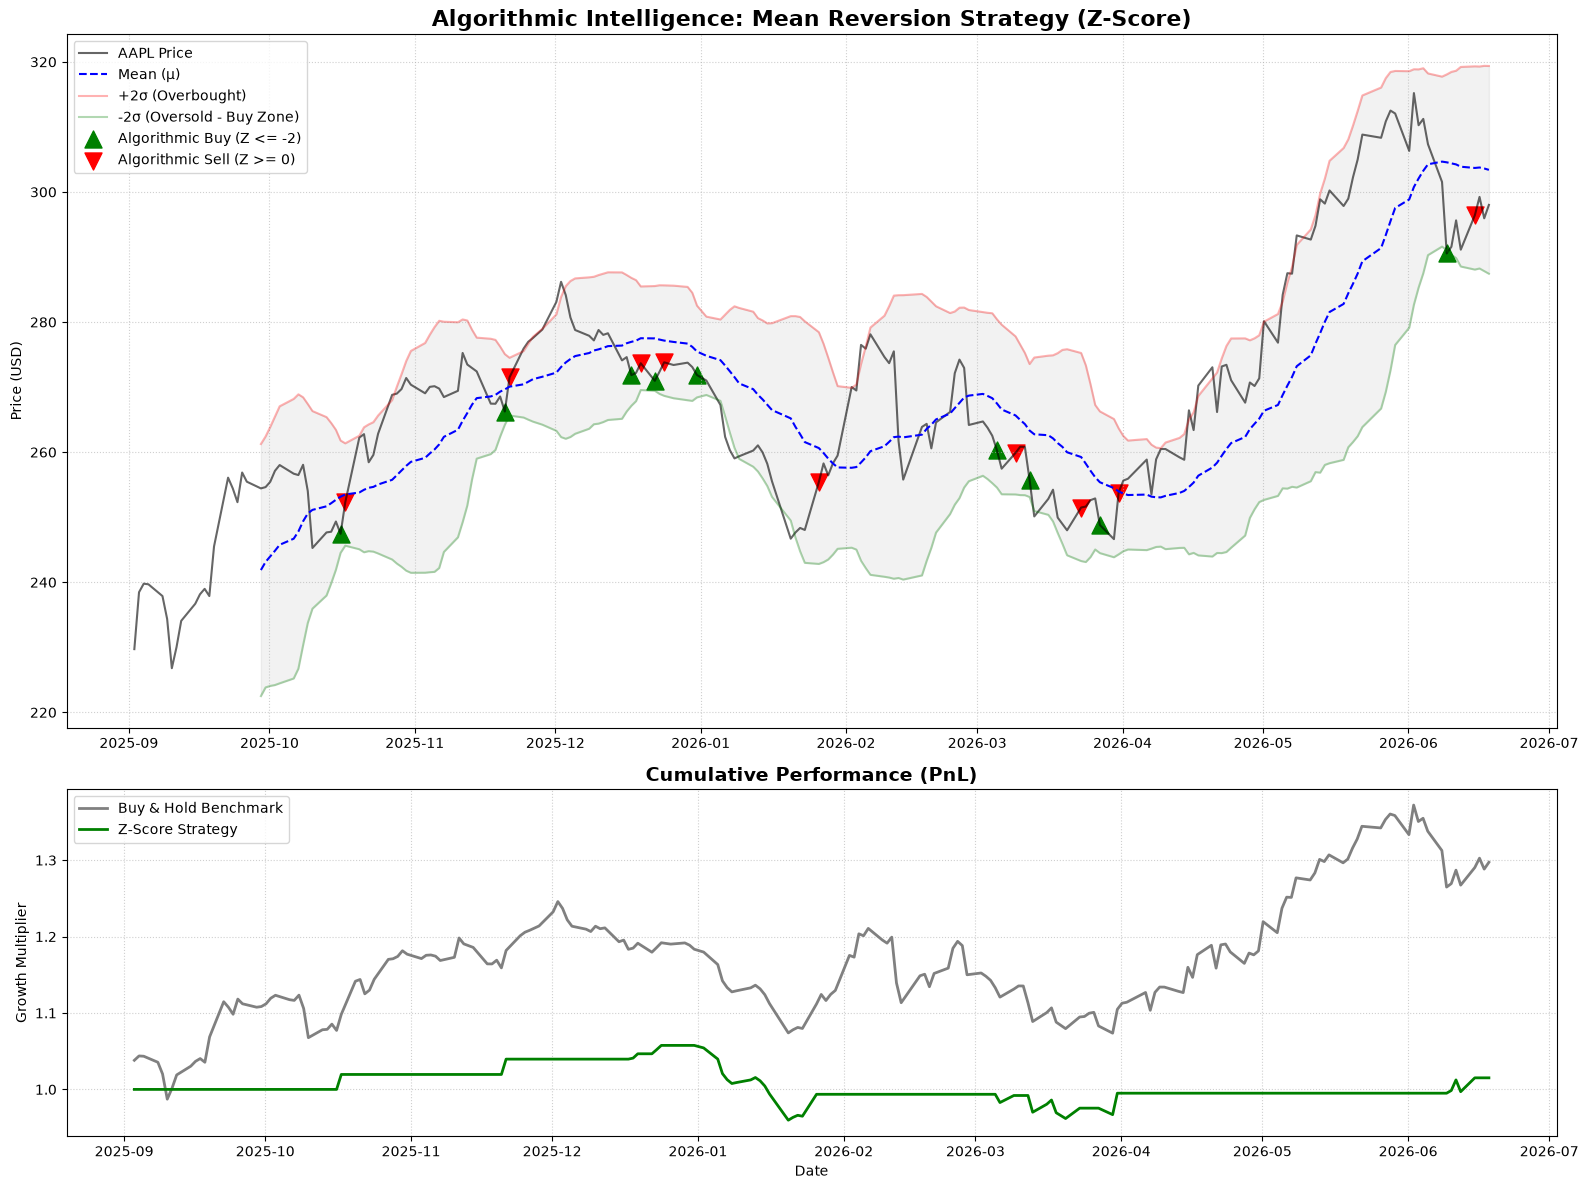

In [33]:
import matplotlib.pyplot as plt
import pandas as pd

print("Processing index and generating visual analytics dashboard...")

plot_df = df.copy()

if isinstance(plot_df.index, pd.MultiIndex):
    plot_df.index = plot_df.index.get_level_values(1)

fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(16, 12),
    gridspec_kw={"height_ratios": [2, 1]}
)

ax1.plot(
    plot_df.index,
    plot_df["close"],
    label="AAPL Price",
    color="black",
    alpha=0.6
)

ax1.plot(
    plot_df.index,
    plot_df["mu"],
    label="Mean (μ)",
    color="blue",
    linestyle="--"
)

ax1.plot(
    plot_df.index,
    plot_df["mu"] + (2 * plot_df["sigma"]),
    label="+2σ (Overbought)",
    color="red",
    alpha=0.3
)

ax1.plot(
    plot_df.index,
    plot_df["mu"] - (2 * plot_df["sigma"]),
    label="-2σ (Oversold - Buy Zone)",
    color="green",
    alpha=0.3
)

ax1.fill_between(
    plot_df.index,
    plot_df["mu"] - (2 * plot_df["sigma"]),
    plot_df["mu"] + (2 * plot_df["sigma"]),
    color="gray",
    alpha=0.1
)

buy_points = plot_df[plot_df["mr_position"] == 1]

ax1.scatter(
    buy_points.index,
    buy_points["close"],
    marker="^",
    color="green",
    s=150,
    label="Algorithmic Buy (Z <= -2)"
)

sell_points = plot_df[plot_df["mr_position"] == -1]

ax1.scatter(
    sell_points.index,
    sell_points["close"],
    marker="v",
    color="red",
    s=150,
    label="Algorithmic Sell (Z >= 0)"
)

ax1.set_title(
    "Algorithmic Intelligence: Mean Reversion Strategy (Z-Score)",
    fontsize=16,
    fontweight="bold"
)

ax1.set_ylabel("Price (USD)")
ax1.legend(loc="upper left")
ax1.grid(True, linestyle=":", alpha=0.6)

plot_df["market_returns"] = plot_df["close"].pct_change()
plot_df["strategy_returns"] = (
    plot_df["mr_signal"].shift(1) * plot_df["market_returns"]
)

plot_df["cum_market"] = (
    1 + plot_df["market_returns"]
).cumprod()

plot_df["cum_strategy"] = (
    1 + plot_df["strategy_returns"]
).cumprod()

ax2.plot(
    plot_df.index,
    plot_df["cum_market"],
    label="Buy & Hold Benchmark",
    color="gray",
    linewidth=2
)

ax2.plot(
    plot_df.index,
    plot_df["cum_strategy"],
    label="Z-Score Strategy",
    color="green",
    linewidth=2
)

ax2.set_title(
    "Cumulative Performance (PnL)",
    fontsize=14,
    fontweight="bold"
)

ax2.set_ylabel("Growth Multiplier")
ax2.set_xlabel("Date")
ax2.legend(loc="upper left")
ax2.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

Generating advanced visual analytics (3D Surface & Heatmaps)...


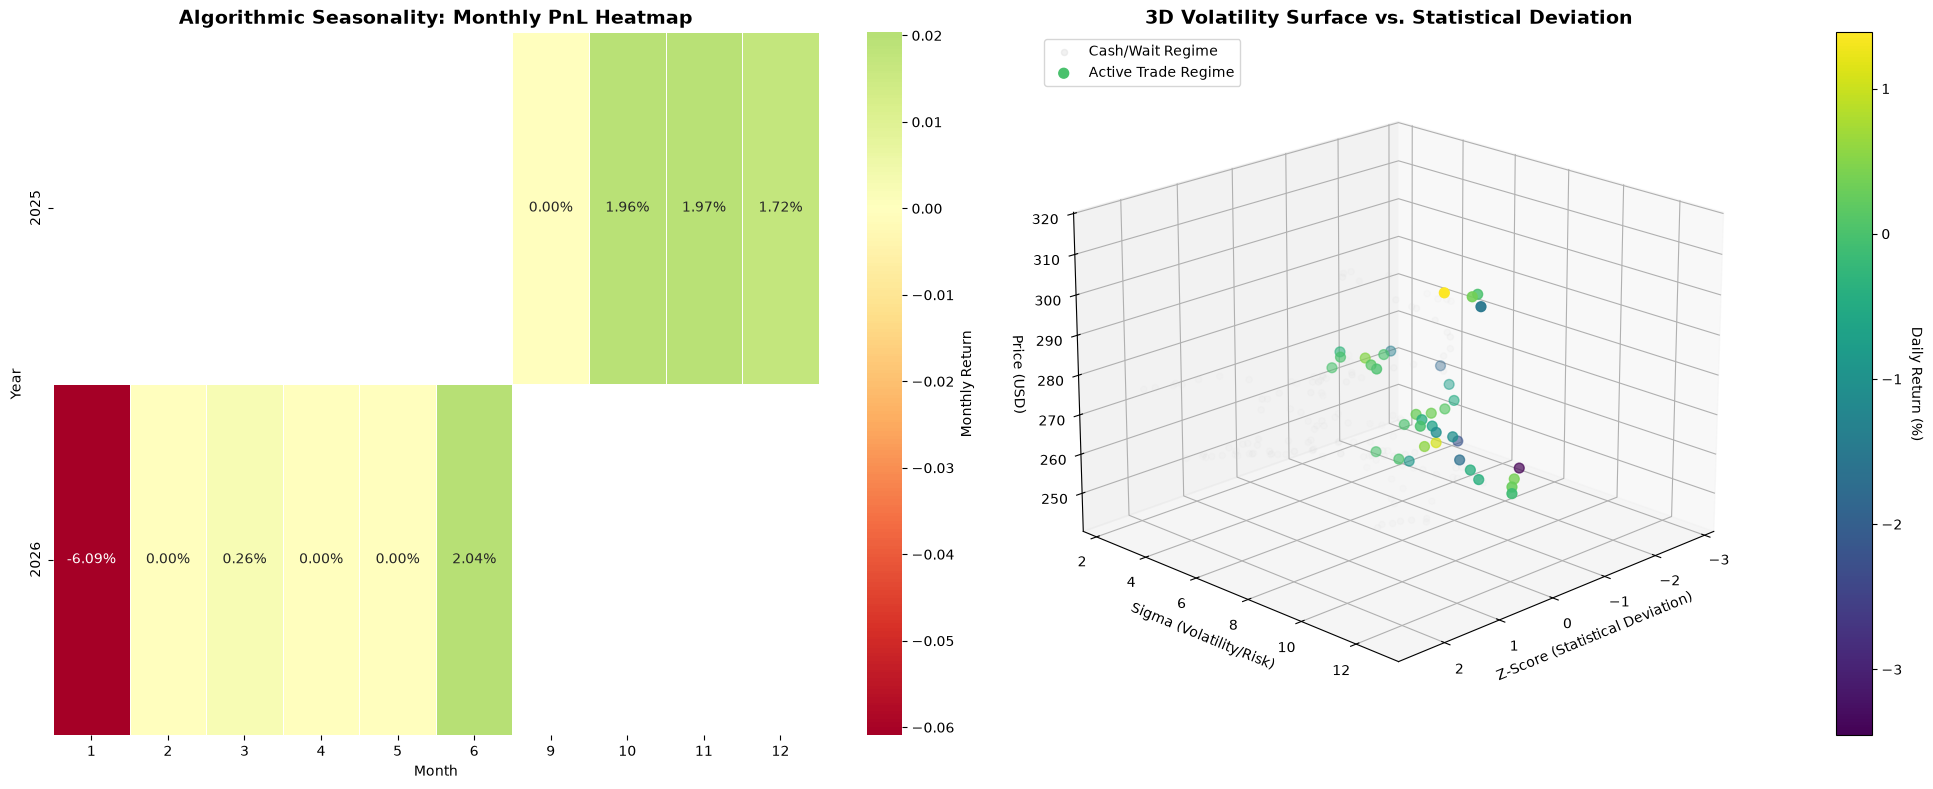

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D

print("Generating advanced visual analytics (3D Surface & Heatmaps)...")

fig = plt.figure(figsize=(20, 8))

ax1 = fig.add_subplot(1, 2, 1)

plot_df["Year"] = pd.to_datetime(plot_df.index).year
plot_df["Month"] = pd.to_datetime(plot_df.index).month

monthly_returns = (
    plot_df.groupby(["Year", "Month"])["strategy_returns"]
    .sum()
    .unstack()
)

sns.heatmap(
    monthly_returns,
    annot=True,
    cmap="RdYlGn",
    center=0,
    fmt=".2%",
    linewidths=0.5,
    cbar_kws={"label": "Monthly Return"},
    ax=ax1
)

ax1.set_title(
    "Algorithmic Seasonality: Monthly PnL Heatmap",
    fontsize=14,
    fontweight="bold"
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Year")

ax2 = fig.add_subplot(1, 2, 2, projection="3d")

buy_state = plot_df[plot_df["mr_signal"] == 1]
wait_state = plot_df[plot_df["mr_signal"] == 0]

ax2.scatter(
    wait_state["z_score"],
    wait_state["sigma"],
    wait_state["close"],
    c="lightgray",
    alpha=0.3,
    label="Cash/Wait Regime",
    s=20
)

sc = ax2.scatter(
    buy_state["z_score"],
    buy_state["sigma"],
    buy_state["close"],
    c=buy_state["strategy_returns"] * 100,
    cmap="viridis",
    marker="o",
    s=50,
    label="Active Trade Regime"
)

cbar = plt.colorbar(sc, ax=ax2, pad=0.1)
cbar.set_label(
    "Daily Return (%)",
    rotation=270,
    labelpad=15
)

ax2.set_title(
    "3D Volatility Surface vs. Statistical Deviation",
    fontsize=14,
    fontweight="bold"
)

ax2.set_xlabel("Z-Score (Statistical Deviation)")
ax2.set_ylabel("Sigma (Volatility/Risk)")
ax2.set_zlabel("Price (USD)")

ax2.view_init(elev=20, azim=45)

ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()